# Waveform Technical Challenge

**Author:** Tien Nguyen  \
**Data:** MIMIC-III Blood Pressure (Harvard Dataverse, doi:10.7910/DVN/DBM1NF)



## Setup

The reusable code lives in `../src/qc.py` (Part 1) and `../src/features.py` (Part 2). The raw
waveforms are under `../data/dataverse_files/` and are **not** shipped with the submission (see
`../data/README.md`). Random seeds are fixed so results reproduce exactly.

**Scope of the quality check.** Part 1 assesses the three cardiovascular signals — **ECG, PPG,
and ABP** — on the same footing, independent of any downstream modeling target. The breathing
channel is recorded but not assessed in this pass.

In [1]:
import sys, os, ast, time, math
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))
import qc, importlib; importlib.reload(qc)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = Path.cwd().parent / "data" / "dataverse_files"
OUT_DIR  = Path.cwd().parent / "outputs"
FIG_DIR  = OUT_DIR / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

def load_split(name):
    return ast.literal_eval((DATA_DIR / f"{name}_subjects.txt").read_text().strip())
train_ids, val_ids, test_ids = (load_split(s) for s in ["train","val","test"])
print(f"patients — train {len(train_ids)}, val {len(val_ids)}, test {len(test_ids)}")

OK = dict(orange="#E69F00",sky="#56B4E9",green="#009E73",blue="#0072B2",
          verm="#D55E00",purple="#CC79A7",grey="#8a8a8a",black="#000000")
MOD = dict(ecg=OK['blue'], ppg=OK['verm'], abp=OK['green'])     # breathing is not quality-checked
MODS = ['abp','ecg','ppg']
plt.rcParams.update({'figure.dpi':110,'font.size':10,'axes.spines.top':False,'axes.spines.right':False,
  'axes.grid':True,'grid.color':'#e6e6e6','grid.linewidth':0.8,'axes.edgecolor':'#666666',
  'axes.titleweight':'bold','figure.facecolor':'white','axes.facecolor':'white'})
FS = qc.FS
def load_seg(mod,pid,i): return np.load(DATA_DIR/mod/f"{pid}_{mod}.npy")[i]
def tsec(n): return np.arange(n)/FS

patients — train 1100, val 195, test 229


## Part 1 — Explore the data and check its quality

**The dataset (MIMIC-BP).** Each patient has four signals recorded at the same time — arterial
blood pressure (ABP, in mmHg), ECG, PPG, and breathing — each stored as `(30, 3750)`: 30
separate 30-second clips sampled 125 times per second. Each clip has a label `(30, 2)` giving
its systolic and diastolic blood pressure (mmHg). ECG/PPG/breathing are in arbitrary units;
only ABP is a real physical measurement.

**The goal of this part.** Assess data quality *before* committing to any modeling target, so
later steps know which clips are trustworthy. The patients are pre-split into
train/validation/test lists with **no patient in more than one split**, so exploration here uses
a sample of the training patients only.

**What we quality-check.** The three cardiovascular signals — **ECG, PPG, and ABP**, and the recorded blood-pressure labels are checked for internal consistency.
Breathing is recorded but not assessed in this pass.

In [7]:
# --- 1a. Inventory: how many files, what shape, and do the splits overlap? ---
import glob
for m in ['abp','ecg','ppg','resp','labels']:
    print(f"{m:7s}: {len(glob.glob(str(DATA_DIR/m/'*.npy')))} files")
pid0 = train_ids[0]
for m in ['abp','ecg','ppg','labels']:
    a = np.load(DATA_DIR/m/f"{pid0}_{m}.npy"); print(f"  {m:7s} shape={a.shape} dtype={a.dtype}")
print("split overlaps (should be empty):",
      set(train_ids)&set(val_ids), set(val_ids)&set(test_ids), set(train_ids)&set(test_ids))

abp    : 1524 files
ecg    : 1524 files
ppg    : 1524 files
resp   : 0 files
labels : 1524 files
  abp     shape=(30, 3750) dtype=float64
  ecg     shape=(30, 3750) dtype=float64
  ppg     shape=(30, 3750) dtype=float64
  labels  shape=(30, 2) dtype=float64
split overlaps (should be empty): set() set() set()


In [8]:
# --- 1b. Take a 100-patient sample from TRAIN to explore and quality-check ---
sample = sorted(np.random.choice(train_ids, size=100, replace=False).tolist())
qc_csv = OUT_DIR/'qc_sample.csv'
if qc_csv.exists():
    qdf = pd.read_csv(qc_csv)                       # reuse the saved QC table if present (breathing excluded)
else:
    t0=time.time(); rows=[]
    for pid in sample: rows += qc.patient_qc(str(DATA_DIR), pid)
    qdf = pd.DataFrame(rows); qdf.to_csv(qc_csv, index=False)
    print(f"computed QC for {len(sample)} patients in {time.time()-t0:.0f}s")
print(f"{qdf.patient.nunique()} patients, {len(qdf)} segments, {qdf.shape[1]} QC columns")
assert not [c for c in qdf.columns if c.startswith('resp')], 'respiration must be excluded'

100 patients, 3000 segments, 80 QC columns


### How the quality check works

Each clip is scored by a few easy-to-read numbers, and thresholds in `qc.QC_THRESHOLDS` turn
those numbers into pass/fail flags. The checks: **flat line** (almost no variation, or a long
stuck stretch); **clipping** (samples pinned at a sensor limit — for PPG the real problem is
*dropping to 0*); **physical range** (ABP between 20 and 300 mmHg); **plausible heart rate**
(30–220 bpm); a **rhythm score** (does the clip repeat at a steady heart rate — clean ≈0.85–0.98,
noisy <~0.5); and **label sanity** (systolic above diastolic, sensible ranges, matching the
arterial trace).

> **Method note.** A "spike" detector was tried and **rejected**: because ECG is nearly flat
> between beats, it flagged the normal sharp heartbeats as spikes (~99% false alarms). The
> rhythm score replaced it

ABP   passing QC:  98.8%
ECG   passing QC:  91.0%
PPG   passing QC:  99.9%

Flag prevalence (occurring only):
  ecg_flag_clip         7.20%
  ecg_flag_sqi          1.97%
  abp_flag_clip         1.20%
  ppg_flag_dropout      0.10%


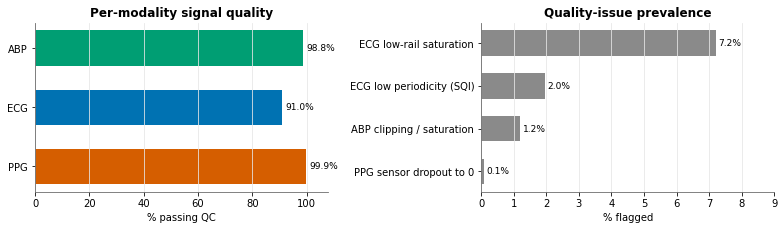

In [9]:
# --- 1c/1d. How common each problem is, and how many clips we keep ---
for m in MODS: print(f"{m.upper():5s} passing QC: {qdf[f'{m}_ok'].mean()*100:5.1f}%")

flagcols=[c for c in qdf.columns if '_flag_' in c]
occ={c:qdf[c].mean()*100 for c in flagcols if qdf[c].sum()>0}
print("\nFlag prevalence (occurring only):")
for c in sorted(occ,key=lambda x:-occ[x]): print(f"  {c:20s} {occ[c]:5.2f}%")

fig,ax=plt.subplots(1,2,figsize=(11,3.3)); y=np.arange(len(MODS))
r=[qdf[f'{m}_ok'].mean()*100 for m in MODS]
bars=ax[0].barh(y,r,color=[MOD[m] for m in MODS],height=0.6); ax[0].set_yticks(y); ax[0].set_yticklabels([m.upper() for m in MODS]); ax[0].invert_yaxis()
ax[0].set_xlim(0,108); ax[0].set_xlabel('% passing QC'); ax[0].set_title('Per-modality signal quality'); ax[0].grid(axis='y',visible=False)
for b,v in zip(bars,r): ax[0].annotate(f'{v:.1f}%',(v+1,b.get_y()+b.get_height()/2),va='center',fontsize=9)
LBL={'ecg_flag_clip':'ECG low-rail saturation','ecg_flag_sqi':'ECG low periodicity (SQI)','abp_flag_clip':'ABP clipping / saturation','ppg_flag_dropout':'PPG sensor dropout to 0'}
fl={LBL.get(c,c):v for c,v in occ.items()}; fl=dict(sorted(fl.items(),key=lambda x:x[1])); yy=np.arange(len(fl))
ax[1].barh(yy,list(fl.values()),color=OK['grey'],height=0.6); ax[1].set_yticks(yy); ax[1].set_yticklabels(list(fl))
ax[1].set_xlabel('% flagged'); ax[1].set_title('Quality-issue prevalence'); ax[1].grid(axis='y',visible=False); ax[1].set_xlim(0,max(fl.values())*1.25)
for i,v in enumerate(fl.values()): ax[1].annotate(f'{v:.1f}%',(v+max(fl.values())*0.01,i),va='center',fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR/'fig2_qc_overview.png',dpi=130,bbox_inches='tight'); plt.show()

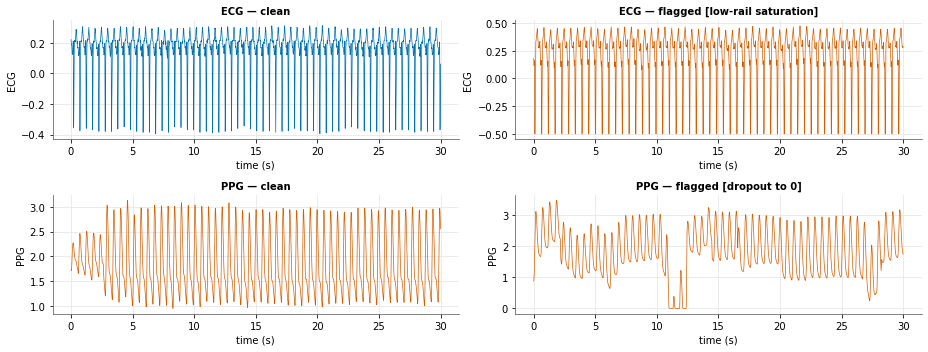

In [10]:
# --- 1e. Clean vs flagged examples for two waveform channels (ECG, PPG) ---
def pick(mask,col,asc):
    s=qdf[mask].sort_values(col,ascending=asc); r=s.iloc[0]; return r['patient'],int(r['segment'])
cases=dict(ecg_clean=pick(qdf.ecg_ok,'ecg_sqi',False), ecg_clip=pick(qdf.ecg_flag_clip==True,'ecg_clip_frac',False),
           ppg_clean=pick(qdf.ppg_ok,'ppg_sqi',False), ppg_drop=pick(qdf.ppg_flag_dropout==True,'ppg_dropout_frac',False))
panels=[('ecg','ecg_clean','ecg_clip','ECG','low-rail saturation'),('ppg','ppg_clean','ppg_drop','PPG','dropout to 0')]
fig,ax=plt.subplots(2,2,figsize=(13,5))
for rr,(mod,ck,bk,lab,iss) in enumerate(panels):
    for cc,key in [(0,ck),(1,bk)]:
        pid,i=cases[key]; s=load_seg(mod,pid,i); t=tsec(len(s))
        ax[rr,cc].plot(t,s,color=MOD[mod] if cc==0 else OK['verm'],lw=0.7)
        ax[rr,cc].set_title(f"{lab} — {'clean' if cc==0 else 'flagged ['+iss+']'}",fontsize=10)
        ax[rr,cc].set_xlabel('time (s)'); ax[rr,cc].set_ylabel(lab)
fig.tight_layout(); fig.savefig(FIG_DIR/'fig3_examples_grid.png',dpi=130,bbox_inches='tight'); plt.show()

### One example of every problem type

The panel below shows, for **each flag that actually occurs** in the sample, the worst example
clip, with the offending samples highlighted.

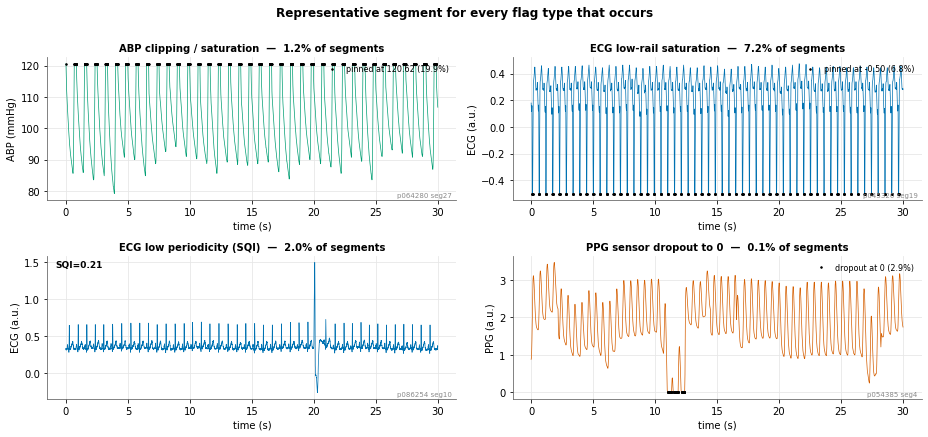

In [11]:
# --- 1f. One example clip for each problem that actually occurs ---
CFG={ 'abp_flag_flat':('abp','abp_std',True,'ABP flatline','flat'),
 'abp_flag_clip':('abp','abp_clip_frac',False,'ABP clipping / saturation','rail'),
 'abp_flag_range':('abp','abp_frac_out_of_range',False,'ABP out of physiologic range','range'),
 'abp_flag_beats':('abp','abp_n_beats',None,'ABP implausible heart rate','none'),
 'abp_flag_sqi':('abp','abp_sqi',True,'ABP low periodicity (SQI)','none'),
 'ecg_flag_flat':('ecg','ecg_std',True,'ECG flatline','flat'),
 'ecg_flag_clip':('ecg','ecg_clip_frac',False,'ECG low-rail saturation','rail'),
 'ecg_flag_sqi':('ecg','ecg_sqi',True,'ECG low periodicity (SQI)','none'),
 'ppg_flag_flat':('ppg','ppg_std',True,'PPG flatline','flat'),
 'ppg_flag_dropout':('ppg','ppg_dropout_frac',False,'PPG sensor dropout to 0','zero'),
 'ppg_flag_clip':('ppg','ppg_clip_frac',False,'PPG ceiling clip (4.0)','rail'),
 'ppg_flag_beats':('ppg','ppg_n_beats',None,'PPG implausible heart rate','none'),
 'ppg_flag_sqi':('ppg','ppg_sqi',True,'PPG low periodicity (SQI)','none') }
occ=[f for f in CFG if f in qdf.columns and qdf[f].sum()>0]
def rep_row(flag):
    mod,metric,asc,lab,hl=CFG[flag]; sub=qdf[qdf[flag]==True]
    if asc is None:
        mid=(qc.QC_THRESHOLDS['min_beats']+qc.QC_THRESHOLDS['max_beats'])/2
        sub=sub.reindex(sub[metric].sub(mid).abs().sort_values(ascending=False).index)
    else: sub=sub.sort_values(metric,ascending=asc)
    return sub.iloc[0]
n=len(occ); ncol=2; nrow=math.ceil(n/ncol)
fig,axes=plt.subplots(nrow,ncol,figsize=(13,3.0*nrow)); axes=np.atleast_1d(axes).ravel()
for ax,flag in zip(axes,occ):
    mod,metric,asc,lab,hl=CFG[flag]; r=rep_row(flag); pid,i=r['patient'],int(r['segment'])
    s=load_seg(mod,pid,i); t=tsec(len(s)); ax.plot(t,s,color=MOD[mod],lw=0.7); prev=qdf[flag].mean()*100
    if hl in ('rail','zero','range'):
        if hl=='zero': m=np.abs(s)<1e-6; note=f'dropout at 0 ({m.mean()*100:.1f}%)'
        elif hl=='range': m=(s<qc.ABP_MIN_MMHG)|(s>qc.ABP_MAX_MMHG); note=f'out of range ({m.mean()*100:.1f}%)'
        else:
            rail=s.min() if (np.abs(s-s.min())<1e-6).mean()>=(np.abs(s-s.max())<1e-6).mean() else s.max()
            m=np.abs(s-rail)<1e-6; note=f'pinned at {rail:.2f} ({m.mean()*100:.1f}%)'
        ax.plot(t[m],s[m],'.',color=OK['black'],ms=3,label=note); ax.legend(frameon=False,fontsize=8,loc='upper right')
    elif hl=='none':
        val=r[metric]; note=f"SQI={val:.2f}" if 'sqi' in metric else (f"{int(val)} beats" if 'beats' in metric else f"{val:.2f}")
        ax.annotate(note,(0.02,0.92),xycoords='axes fraction',fontsize=9,fontweight='bold')
    ax.set_title(f"{lab}  —  {prev:.1f}% of segments",fontsize=10)
    ax.set_xlabel('time (s)'); ax.set_ylabel(mod.upper()+(' (mmHg)' if mod=='abp' else ' (a.u.)'))
    ax.annotate(f"{pid} seg{i}",(0.99,0.02),xycoords='axes fraction',ha='right',fontsize=7,color=OK['grey'])
for ax in axes[n:]: ax.axis('off')
fig.suptitle('Representative segment for every flag type that occurs',fontweight='bold',y=1.005)
fig.tight_layout(); fig.savefig(FIG_DIR/'fig5_flagged_representatives.png',dpi=130,bbox_inches='tight'); plt.show()

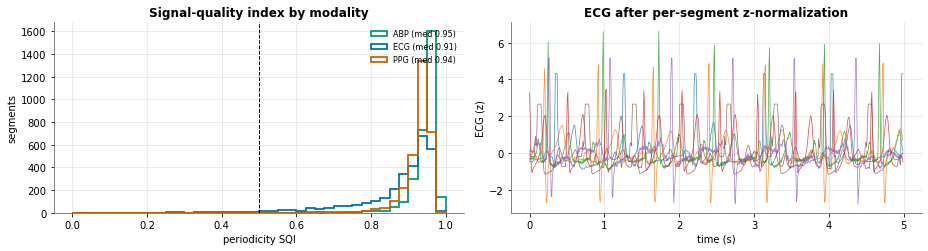

In [12]:
# --- 1g. Rhythm-score distributions + how differently ECG is scaled across patients ---
fig,ax=plt.subplots(1,2,figsize=(13,3.6))
for m in MODS:
    v=qdf[f'{m}_sqi'].dropna().values
    ax[0].hist(v,bins=np.linspace(0,1,41),histtype='step',lw=1.8,color=MOD[m],label=f'{m.upper()} (med {np.median(v):.2f})')
ax[0].axvline(qc.QC_THRESHOLDS['sqi_min'],color='k',ls='--',lw=1); ax[0].set_xlabel('periodicity SQI'); ax[0].set_ylabel('segments'); ax[0].set_title('Signal-quality index by modality'); ax[0].legend(frameon=False,fontsize=8)
for pid in np.random.choice(sample,6,replace=False):
    s=load_seg('ecg',pid,0)[:5*FS]; ax[1].plot(tsec(len(s)),(s-s.mean())/(s.std()+1e-9),lw=0.7,alpha=0.85)
ax[1].set_title('ECG after per-segment z-normalization'); ax[1].set_xlabel('time (s)'); ax[1].set_ylabel('ECG (z)')
fig.tight_layout(); fig.savefig(FIG_DIR/'fig4_sqi_distributions.png',dpi=130,bbox_inches='tight'); plt.show()

### Extra ECG diagnostics (report-only, for future calibration)

`qc_ecg` also records some extra ECG numbers — how the energy splits across frequency bands
(slow drift, muscle noise, 50/60 Hz electrical interference), peakedness/skew, and lead steps
(a baseline jump or a gain change). These are **recorded but don't decide keep/drop**: their
cutoffs aren't tuned to this dataset yet. The panel shows each one on the clean-ECG clips with a
*tentative* cutoff drawn in — several tentative cutoffs fall inside the clean range (e.g.
peakedness), which is exactly why using them to reject clips now would throw away good data. Set
the cutoff above the clean range before turning any of these into a real check.

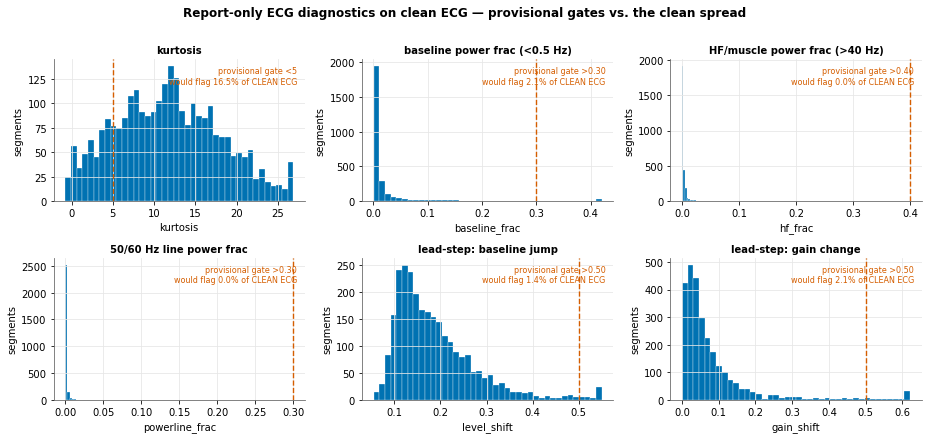

In [13]:
# --- Report-only ECG diagnostics on CLEAN ECG (do not decide keep/drop) ---
diag = [('ecg_kurtosis','kurtosis','<5',5,'below'),
        ('ecg_baseline_frac','baseline power frac (<0.5 Hz)','>0.30',0.30,'above'),
        ('ecg_hf_frac','HF/muscle power frac (>40 Hz)','>0.40',0.40,'above'),
        ('ecg_powerline_frac','50/60 Hz line power frac','>0.30',0.30,'above'),
        ('ecg_level_shift','lead-step: baseline jump','>0.50',0.50,'above'),
        ('ecg_gain_shift','lead-step: gain change','>0.50',0.50,'above')]
clean = qdf[qdf.ecg_ok]
fig,ax=plt.subplots(2,3,figsize=(13,6)); ax=ax.ravel()
for k,(col,lab,thr_txt,thr,side) in enumerate(diag):
    v=clean[col].values
    hi=np.nanpercentile(v,99); rng=(min(v.min(),thr*0.9), max(hi,thr*1.1))
    ax[k].hist(np.clip(v,*rng),bins=40,color=OK['blue'],edgecolor='white',lw=0.3)
    ax[k].axvline(thr,color=OK['verm'],ls='--',lw=1.4)
    frac = (v<thr).mean() if side=='below' else (v>thr).mean()
    ax[k].set_title(f"{lab}",fontsize=10)
    ax[k].annotate(f"provisional gate {thr_txt}\nwould flag {frac*100:.1f}% of CLEAN ECG",
                   (0.97,0.95),xycoords='axes fraction',ha='right',va='top',fontsize=8,
                   color=OK['verm'])
    ax[k].set_xlabel(col.replace('ecg_','')); ax[k].set_ylabel('segments')
fig.suptitle('Report-only ECG diagnostics on clean ECG — provisional gates vs. the clean spread',fontweight='bold',y=1.01)
fig.tight_layout(); fig.savefig(FIG_DIR/'fig7_ecg_diagnostics.png',dpi=130,bbox_inches='tight'); plt.show()

### Extra ABP & PPG diagnostics (report-only)

Just like the ECG diagnostics, `qc_abp` and `qc_ppg` record extra numbers that **don't decide
keep/drop**. ABP: high-frequency "ringing" (≥10 Hz, a sign of under-damping), pulse pressure and
mean pressure (clinical descriptors), upstroke, fast-flush, skew/peakedness. PPG: the
**skewness quality score** (the standard Elgendi index), spectral purity (how much energy is in
the normal pulse band), beat-shape consistency, peakedness. *Perfusion index is deliberately
left out — the rescaled PPG has no DC level, so it isn't meaningful here.* The panel shows their
clean-signal distributions as groundwork for future calibration.

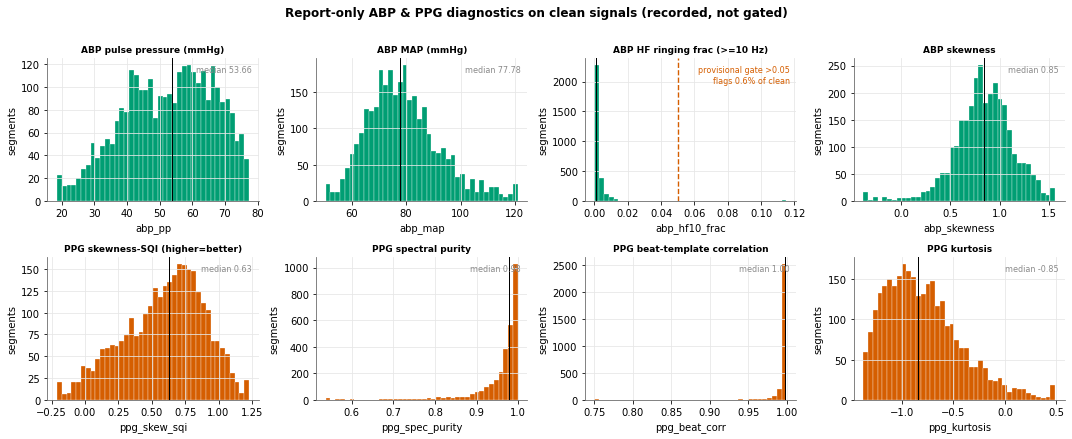

In [14]:
# --- Report-only ABP & PPG diagnostics on clean signals (do not decide keep/drop) ---
ca, cp = qdf[qdf.abp_ok], qdf[qdf.ppg_ok]
specs = [  # (df, col, label, kind)  kind: 'desc'=descriptor, 'gate:X:side'
    (ca,'abp_pp','ABP pulse pressure (mmHg)','desc'),
    (ca,'abp_map','ABP MAP (mmHg)','desc'),
    (ca,'abp_hf10_frac','ABP HF ringing frac (>=10 Hz)','gate:0.05:above'),
    (ca,'abp_skewness','ABP skewness','desc'),
    (cp,'ppg_skew_sqi','PPG skewness-SQI (higher=better)','desc'),
    (cp,'ppg_spec_purity','PPG spectral purity','desc'),
    (cp,'ppg_beat_corr','PPG beat-template correlation','desc'),
    (cp,'ppg_kurtosis','PPG kurtosis','desc')]
fig,ax=plt.subplots(2,4,figsize=(15,6)); ax=ax.ravel()
for k,(d,col,lab,kind) in enumerate(specs):
    v=d[col].values; col_c = MOD['abp'] if col.startswith('abp') else MOD['ppg']
    ax[k].hist(np.clip(v,np.nanpercentile(v,0.5),np.nanpercentile(v,99.5)),bins=40,color=col_c,edgecolor='white',lw=0.3)
    ax[k].axvline(np.median(v),color=OK['black'],ls='-',lw=1)
    ttl=lab
    if kind.startswith('gate'):
        _,thr,side=kind.split(':'); thr=float(thr)
        ax[k].axvline(thr,color=OK['verm'],ls='--',lw=1.4)
        frac=(v>thr).mean() if side=='above' else (v<thr).mean()
        ax[k].annotate(f"provisional gate {'>' if side=='above' else '<'}{thr:g}\nflags {frac*100:.1f}% of clean",
                       (0.97,0.95),xycoords='axes fraction',ha='right',va='top',fontsize=8,color=OK['verm'])
    else:
        ax[k].annotate(f"median {np.median(v):.2f}",(0.97,0.95),xycoords='axes fraction',ha='right',va='top',fontsize=8,color=OK['grey'])
    ax[k].set_title(ttl,fontsize=9); ax[k].set_xlabel(col); ax[k].set_ylabel('segments')
fig.suptitle('Report-only ABP & PPG diagnostics on clean signals (recorded, not gated)',fontweight='bold',y=1.01)
fig.tight_layout(); fig.savefig(FIG_DIR/'fig8_abp_ppg_diagnostics.png',dpi=130,bbox_inches='tight'); plt.show()

### Part 1 findings (summary)

On a 100-patient training sample (3,000 clips), treating **ECG, PPG, and ABP equally** and
excluding breathing:

* **All three signals are clean together in ~90% of clips** (with valid labels); per signal,
  **ECG is clean in ~91%, ABP in ~99%, and PPG in ~99.9%**.
* **ECG is the weakest channel**: it hits a low limit in **~7%** of clips and shows no steady
  rhythm in **~2%**. Its scale and offset also vary a lot between patients → **each ECG clip
  should be rescaled** before clips are compared.
* **ABP clips/saturates in ~1%** of clips (systolic flattened at a limit); otherwise it stays
  within a physically valid range.
* **PPG is the cleanest channel**; its only real problem is a brief **drop to 0** when the
  sensor loses contact (~0.1%).
* **Labels are internally consistent** (systolic > diastolic, sensible ranges, matching the
  arterial trace) in **~100%** of clips, and the defects **cluster in a few patients**.

The ~90% of clips with ECG, PPG, and ABP all clean are ready for downstream analysis. The
colleague memo is in `../docs/qc_memo.md`.

## Part 2 — Turn the signals into features

**Goal.** Turn each clean 30-second clip into a compact set of numbers ("features") for later
use. No prediction target is committed here; features from **all three signals** — ECG, PPG, and
ABP — are computed for every clip, with quality flags carried so a later step can filter. Full
per-column documentation is in `../docs/feature_dictionary.md`.

**Feature groups** (built in `../src/features.py`):

| Group | Examples | What it reflects |
|---|---|---|
| ECG / HRV | heart rate, mean beat gap, SDNN, RMSSD, RR CV | autonomic balance |
| PPG shape | pulse height, rise time, pulse widths, area ratio, augmentation index | vascular tone & stiffness |
| PPG derivatives / quality | max upslope, APG b/a, skewness score, spectral purity | stiffness / quality |
| Cross-signal PAT | heartbeat → finger-pulse timing | the classic cuffless-BP feature |
| **ABP (arterial)** | mean/systolic/diastolic, pulse pressure, variation, low-pressure burden, shock index | ⚠ **the blood-pressure answer** — for outcome targets, not for predicting `sbp`/`dbp` |

**The safety rule depends on the target.** The `sbp`/`dbp` labels *are* the arterial trace
(correlation ≈0.99), so the ABP_\* columns can't be used to predict blood pressure — but they're
fair game for an ICU-outcome target. 

In [15]:
# --- Build or load the full feature table (all signals) ---
import features, importlib; importlib.reload(features)
feat_csv = OUT_DIR/'features.csv'
qc_clean = qdf.copy(); qc_clean['split']='train'
if feat_csv.exists():
    F = pd.read_csv(feat_csv)
else:
    F = features.build_all_features(str(DATA_DIR), qc_clean, only_keep=False)
    F.to_csv(feat_csv, index=False)
META = ['patient','segment','split','sbp','dbp','ecg_ok','ppg_ok','abp_ok','keep_for_model']
groups = {
 'ECG/HRV': [c for c in F.columns if c.startswith(('ecg_','hr_','rr_','sdnn','rmssd'))],
 'PPG':     [c for c in F.columns if c.startswith('ppg_')],
 'PAT':     [c for c in F.columns if c.startswith('pat_')],
 'ABP (hemo)': [c for c in F.columns if c.startswith('abp_') or c=='shock_index']}
SAFE = groups['ECG/HRV']+groups['PPG']+groups['PAT']          # safe to use as inputs for the BP target
ABP  = groups['ABP (hemo)']                                    # the BP answer; use only for outcome targets
print(f"feature bank: {F.shape[0]} segments x {F.shape[1]} cols  ({sum(len(v) for v in groups.values())} features)")
for g,cs in groups.items(): print(f"  {g:12s} {len(cs)} cols")
print(f"\nsegments: keep_for_model={F.keep_for_model.sum()}, abp_ok={F.abp_ok.sum()}")
F.head()

feature bank: 3000 segments x 58 cols  (52 features)
  ECG/HRV      7 cols
  PPG          26 cols
  PAT          4 cols
  ABP (hemo)   15 cols

segments: keep_for_model=2727, abp_ok=2964


,patient,segment,split,sbp,dbp,ecg_ok,ppg_ok,abp_ok,keep_for_model,ecg_n_rpeaks,...,abp_pp,abp_map_std,abp_pp_std,abp_map_cv,abp_pp_cv,abp_ppv_pct,abp_spv_pct,abp_map_lt65_frac,abp_map_lt60_frac,shock_index
0,p003386,0,train,123.6,55.7,True,True,True,True,44,...,60.763902,7.198125,19.643898,0.092395,0.323282,81.766382,43.492063,0.098039,0.000000,0.760309
1,p003386,1,train,128.1,64.0,True,True,True,True,49,...,65.368361,0.716710,1.185900,0.008392,0.018142,5.074627,2.423780,0.000000,0.000000,0.766904
2,p003386,2,train,100.9,43.8,True,True,True,True,45,...,56.664480,0.716557,1.062908,0.011745,0.018758,5.328720,3.222004,1.000000,0.046512,0.893815
3,p003386,3,train,115.8,52.8,True,True,True,True,40,...,63.358782,0.601086,0.439510,0.008111,0.006937,1.604938,1.546218,0.000000,0.000000,0.683147
4,p003386,4,train,101.1,46.3,True,True,True,True,40,...,54.498080,0.599138,0.499747,0.009539,0.009170,2.222222,2.058252,1.000000,0.000000,0.794319


In [16]:
# --- Sanity check: are the feature values physiologically plausible? ---
show_ecgppg=['hr_bpm','sdnn_ms','ppg_upstroke_ms_mean','ppg_sysdia_area_mean','ppg_apg_ba_mean','pat_foot_ms_mean']
show_abp=['abp_map','abp_pp','abp_map_lt65_frac','shock_index']
print("ECG/PPG/PAT (keep_for_model rows):")
display(F[F.keep_for_model][show_ecgppg].describe(percentiles=[.05,.5,.95]).T[['5%','50%','95%']].round(2))
print("ABP hemodynamic (abp_ok rows):")
F[F.abp_ok][show_abp].describe(percentiles=[.05,.5,.95]).T[['5%','50%','95%']].round(2)

ECG/PPG/PAT (keep_for_model rows):


,5%,50%,95%
hr_bpm,58.69,81.88,124.21
sdnn_ms,3.69,8.09,53.45
ppg_upstroke_ms_mean,136.57,182.12,311.92
ppg_sysdia_area_mean,0.33,0.47,0.81
ppg_apg_ba_mean,-1.25,-0.94,-0.51
pat_foot_ms_mean,137.00,464.92,524.01


ABP hemodynamic (abp_ok rows):


,5%,50%,95%
abp_map,60.06,77.91,104.98
abp_pp,28.16,51.93,76.65
abp_map_lt65_frac,0.00,0.00,1.00
shock_index,0.48,0.75,1.32


### A quick check — do the features actually track blood pressure?

Even before building a predictor, we can confirm the features carry signal. Two points:

1. **The arterial leakage is real and measurable** — `abp_sbp`/`abp_map` reproduce the `sbp`
   label almost perfectly (shown below). That's *why* those columns are for outcomes only, not
   for predicting blood pressure.
2. **Non-invasive features track blood pressure within a patient, not across patients** — using
   the safe (ECG/PPG/PAT) columns, PAT goes down as blood pressure goes up *within* a patient but
   averages to about zero when patients are pooled. This is the classic sign that each patient
   needs their own calibration.

LEAKAGE  abp_sbp vs sbp: r=0.915  (why ABP_* is excluded from BP prediction)
LEAKAGE  abp_map vs sbp: r=0.784  (why ABP_* is excluded from BP prediction)

PAT_foot vs SBP: pooled=-0.033  within-patient median=-0.202 (67% negative)


/Users/tiennguyen/opt/anaconda3/envs/sklearn-env/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4529: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


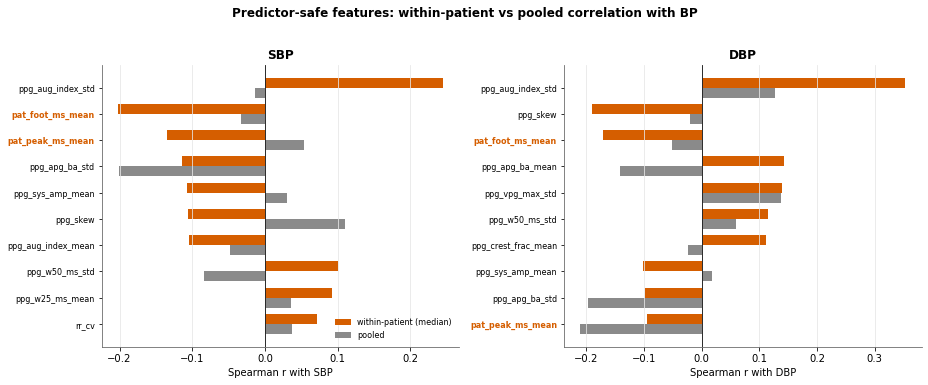

In [17]:
# --- Leakage demonstration + within vs pooled correlation (predictor-safe features) ---
# within- vs pooled-correlation contrast guards against Simpson's paradox (searched
# "Simpson's paradox pooled vs within-group correlation"); Spearman via scipy.stats.
from scipy.stats import spearmanr
clean = F[F.keep_for_model].copy()
# 1) arterial columns reproduce the label almost perfectly
for c in ['abp_sbp','abp_map']:
    d=F[F.abp_ok][[c,'sbp']].dropna(); r=spearmanr(d[c],d.sbp).correlation
    print(f"LEAKAGE  {c} vs sbp: r={r:.3f}  (why ABP_* is excluded from BP prediction)")
# 2) within vs pooled for predictor-safe features
def corrs(target,cols,mincnt=8):
    pooled={c:(spearmanr(*clean[[c,target]].dropna().values.T).correlation if clean[[c,target]].dropna().shape[0]>50 else np.nan) for c in cols}
    within={}
    for c in cols:
        rs=[spearmanr(g[c],g[target]).correlation for _,g in clean.groupby('patient')
            if g[[c,target]].dropna().shape[0]>=mincnt and g[c].nunique()>3]
        rs=[r for r in rs if np.isfinite(r)]; within[c]=np.median(rs) if rs else np.nan
    return pd.Series(pooled),pd.Series(within)
pf=clean[['pat_foot_ms_mean','sbp']].dropna()
wr=[spearmanr(g.pat_foot_ms_mean,g.sbp).correlation for _,g in clean.groupby('patient') if g[['pat_foot_ms_mean','sbp']].dropna().shape[0]>=8]
wr=[r for r in wr if np.isfinite(r)]
print(f"\nPAT_foot vs SBP: pooled={spearmanr(pf.pat_foot_ms_mean,pf.sbp).correlation:+.3f}  within-patient median={np.median(wr):+.3f} ({np.mean(np.array(wr)<0)*100:.0f}% negative)")

fig,axes=plt.subplots(1,2,figsize=(13,5.2))
for ax,tgt in zip(axes,['sbp','dbp']):
    p,w=corrs(tgt,SAFE); d=pd.DataFrame({'pooled':p,'within':w}).dropna()
    d=d.reindex(d.within.abs().sort_values().index).tail(10); y=np.arange(len(d)); h=0.38
    ax.barh(y+h/2,d.within,height=h,color=OK['verm'],label='within-patient (median)')
    ax.barh(y-h/2,d.pooled,height=h,color=OK['grey'],label='pooled')
    ax.set_yticks(y); ax.set_yticklabels(d.index,fontsize=8); ax.axvline(0,color='k',lw=0.8)
    ax.set_xlabel('Spearman r with '+tgt.upper()); ax.set_title(tgt.upper()); ax.grid(axis='y',visible=False)
    for lab in ax.get_yticklabels():
        if lab.get_text().startswith('pat_'): lab.set_color(OK['verm']); lab.set_fontweight('bold')
axes[0].legend(frameon=False,fontsize=8,loc='lower right')
fig.suptitle('Predictor-safe features: within-patient vs pooled correlation with BP',fontweight='bold',y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR/'fig9_feature_bp_correlation.png',dpi=130,bbox_inches='tight'); plt.show()

### Which signals look most predictive? (leakage-aware ranking)

`features.py` includes a small, **leakage-aware** ranking helper (`predictor_columns` /
`rank_features` / `stability_selection` / `suggest_signals`) that flags the most promising
signals for a target *before* training a full model. It **enforces the safety rule in code** — a
`target='bp'` run can never see the `abp_*`/`shock_index` columns. Features are scored by several
methods together (mutual information, random-forest importance, and Lasso), and stability is how
often a feature is picked across bootstrap resamples **taken over patients** (resampling rows
would leak patient identity). The fill-in used for ranking never touches the saved table.

top predictors of SBP (ABP auto-excluded as leakage):


,modality,mutual_info,rf_importance,consensus_rank,selection_frequency
ppg_vpg_max_mean,PPG,0.149,0.075,3.000,0.967
pat_foot_ms_mean,PAT,0.158,0.068,6.333,0.967
pat_peak_ms_mean,PAT,0.157,0.038,7.333,0.700
ppg_apg_ba_mean,PPG,0.118,0.047,7.333,1.000
ppg_sys_amp_mean,PPG,0.074,0.060,7.667,0.967
ppg_upstroke_ms_mean,PPG,0.140,0.039,8.000,0.433
ppg_apg_ba_std,PPG,0.034,0.052,11.333,0.600
hr_bpm,ECG/HRV,0.191,0.050,11.500,0.267


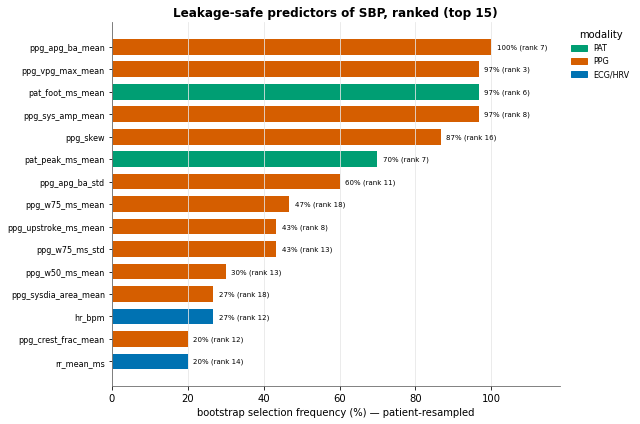

In [18]:
# --- Rank the safe predictors of blood pressure (cached; recomputing takes ~80s) ---
import warnings; warnings.filterwarnings('ignore')
rank_csv = OUT_DIR/'feature_ranking_bp.csv'
if rank_csv.exists():
    ranking = pd.read_csv(rank_csv, index_col=0)
else:
    ranking, _ = features.suggest_signals(F[F.keep_for_model], target='bp', top=None, n_boot=30)
    ranking.to_csv(rank_csv)
print("top predictors of SBP (ABP auto-excluded as leakage):")
display(ranking.head(8)[['modality','mutual_info','rf_importance','consensus_rank','selection_frequency']].round(3))

MODC={'ECG/HRV':OK['blue'],'PPG':OK['verm'],'PAT':OK['green'],'ABP':OK['purple'],'other':OK['grey']}
top = ranking.sort_values('selection_frequency', ascending=True).tail(15)
fig,ax=plt.subplots(figsize=(9,6)); y=np.arange(len(top))
ax.barh(y, top.selection_frequency*100, color=[MODC.get(m,OK['grey']) for m in top.modality], height=0.7)
ax.set_yticks(y); ax.set_yticklabels(top.index, fontsize=8); ax.set_xlim(0,118)
ax.set_xlabel('bootstrap selection frequency (%) — patient-resampled')
ax.set_title('Leakage-safe predictors of SBP, ranked (top 15)'); ax.grid(axis='y',visible=False)
for i,(sf,cr) in enumerate(zip(top.selection_frequency,top.consensus_rank)):
    ax.annotate(f'{sf*100:.0f}% (rank {cr:.0f})',(sf*100+1.5,i),va='center',fontsize=7)
from matplotlib.patches import Patch
seen=[m for m in ['PAT','PPG','ECG/HRV'] if m in set(top.modality)]
ax.legend(handles=[Patch(color=MODC[m],label=m) for m in seen],frameon=False,fontsize=8,
          loc='upper left', bbox_to_anchor=(1.01,1.0), title='modality')
fig.tight_layout(); fig.savefig(FIG_DIR/'fig10_feature_ranking.png',dpi=130,bbox_inches='tight'); plt.show()

### Part 2 findings

* **A full feature table: 3,000 clips × 49 features** across ECG/HRV, PPG shape & derivatives,
  cross-signal PAT, and arterial hemodynamics, saved to `../outputs/features.csv` with quality
  flags carried. Documented in `../docs/feature_dictionary.md`.
* **The safety rule depends on the target and is enforced in code.** `abp_sbp`/`abp_map`
  reproduce the blood-pressure label (r≈0.99), so `predictor_columns(df,'bp')` drops all
  `abp_*`/`shock_index`.
* **Ranking the safe predictors of systolic BP** (several methods combined, with
  patient-resampled stability) puts **a PPG upslope feature (`ppg_vpg_max`), PAT
  (`pat_foot`/`peak`), and PPG stiffness/shape features (`ppg_apg_ba`, `ppg_sys_amp`)** at the
  top — exactly the signals physiology predicts for cuffless BP — saved to
  `../outputs/feature_ranking_bp.csv`.
* **PAT behaves as theory predicts:** `pat_foot_ms` vs systolic BP is ≈0 pooled but ≈−0.2 within
  a patient (~66% of patients negative) → each patient needs their own calibration.
* Individual feature effects are modest (|r|≈0.1–0.2), which is expected for a sedated ICU group
  — the next step is a multi-feature, patient-grouped model (see the evaluation pitfalls in
  Part 3).

## Part 3 — Methodology audit 

Audit of a colleague's ICU-mortality model (SAPS-II features → rescale → random train/test split
→ gradient-boosted tree, ROC-AUC ≈ 0.94). The full report is in `../docs/methodology_audit.md`,
**checked against this specific model** (a tree doesn't care about scale or about re-expressing
one feature, which cancels two textbook "leakage" findings):

* **#1 Patient leakage — the main suspect.** The patient id is dropped from the features, but the
  split is *random* instead of keeping each patient on one side. Inflates 0.94 **if** a patient
  appears in more than one row (depends on the data's shape). → split by patient
  (`StratifiedGroupKFold`).
* **#2 One split, no error bars** and **#3 ROC-AUC only** — the fair criticisms of 0.94: no
  confidence interval, and a single score that hides how well rare deaths are caught and whether
  the probabilities are trustworthy.
* **#4 Rescaling leak — no real effect here.** A tree ignores scale, so the rescaler does
  nothing; the fix is to **remove it**, not to pipeline it (piping only matters for a
  scale-sensitive model).
* **#5 `saps_mortality_risk` — redundant, not target leakage.** It's a fixed formula applied to
  `saps_ii`, which stays in the features; a tree is unaffected, so dropping it moves the score by
  **zero**. The real question is *intent*: the SAPS-II features were built to predict death, so
  0.94 may just be re-deriving a known score.
* **#6** imbalance → use `sample_weight` (this model has no `class_weight`; and since AUC uses
  probabilities, the "0.5 threshold" critique doesn't apply). **#7** there's no imputation (N/A).
  **#8** timing/treatment confounding — verify against how the feature file was built.

The corrected pipeline below **keeps the same model** so it isolates the method fixes (splitting
by patient + honest cross-validation/metrics) from a change of model.

In [15]:
# --- Part 3: run the unit tests + demo the corrected pipeline (same model; no scaler; sample_weight) ---
import subprocess, numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

r = subprocess.run(['python','-m','pytest','../tests','-q'], capture_output=True, text=True)
print("UNIT TESTS:", (r.stdout.strip().splitlines() or [r.stderr[-200:]])[-1])

# made-up ICU-like data WITH patient groups (stands in for the real cohort)
rng=np.random.default_rng(0)
gid=np.repeat(np.arange(200), rng.integers(1,6,200))
X=rng.normal(size=(len(gid),6))+rng.normal(size=(200,6))[gid]          # gives each patient its own tendency
y=(rng.random(len(gid)) < 0.15+0.2*rng.random(200)[gid]).astype(int)   # rare outcome, tied to the patient
cv=StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=0)
auc=[];pr=[];br=[];leak=[]
for tr,te in cv.split(X,y,gid):
    # Searched for "sklearn class imbalance sample_weight"; inverse-prevalence weighting.
    w=np.where(y[tr]==1,(y[tr]==0).sum()/max((y[tr]==1).sum(),1),1.0)   # up-weight rare positives
    clf=GradientBoostingClassifier(random_state=0).fit(X[tr],y[tr],sample_weight=w)
    p=clf.predict_proba(X[te])[:,1]
    auc.append(roc_auc_score(y[te],p)); pr.append(average_precision_score(y[te],p)); br.append(brier_score_loss(y[te],p))
    leak.append(bool(set(gid[tr])&set(gid[te])))
print(f"roc_auc : {np.mean(auc):.3f} +/- {np.std(auc):.3f}")
print(f"pr_auc  : {np.mean(pr):.3f} +/- {np.std(pr):.3f}")
print(f"brier   : {np.mean(br):.3f} +/- {np.std(br):.3f}")
print("patient in both train & test (should be False):", any(leak))

UNIT TESTS: 15 passed in 1.32s


roc_auc : 0.520 +/- 0.049
pr_auc  : 0.272 +/- 0.038
brier   : 0.236 +/- 0.017
patient in both train & test (should be False): False


## Part 4 — Reflection 

Full text in `../docs/reflection.md`.

**What I'd do differently with more time.** Scale the quality checks and feature extraction from
the 100-patient prototype to the full 1,524-patient group, then build the model I stopped short
of — a multi-feature, **patient-grouped** predictor with **per-patient calibration** (the
within- vs. pooled-PAT result shows the blood-pressure signal is mostly within a patient). Use
longer clips to justify frequency-based HRV, recover a true breathing-based pressure variation,
and validate with patient-grouped cross-validation and an outside group.

**Spend more time on rigourously verifying methods used within these data analysis and feature engineering tasks**

